In [3]:
# Master : final project
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Install and Import libraries:**

In [4]:
import os
import numpy as np
import librosa
from skimage.transform import resize
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

from scipy.io import arff
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from PIL import Image
import pickle

# **Download Dataset(horizontal):**



In [5]:
!wget 'r' https://www.timeseriesclassification.com/aeon-toolkit/EOGHorizontalSignal.zip

--2026-07-07 12:02:36--  http://r/
Resolving r (r)... failed: Name or service not known.
wget: unable to resolve host address ‘r’
--2026-07-07 12:02:36--  https://www.timeseriesclassification.com/aeon-toolkit/EOGHorizontalSignal.zip
Resolving www.timeseriesclassification.com (www.timeseriesclassification.com)... 185.151.30.212
Connecting to www.timeseriesclassification.com (www.timeseriesclassification.com)|185.151.30.212|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8167785 (7.8M) [application/zip]
Saving to: ‘EOGHorizontalSignal.zip’

EOGHorizontalSignal 100%[===================>]   7.79M  5.02MB/s    in 1.6s    

2026-07-07 12:02:38 (5.02 MB/s) - ‘EOGHorizontalSignal.zip’ saved [8167785/8167785]

FINISHED --2026-07-07 12:02:38--
Total wall clock time: 2.2s
Downloaded: 1 files, 7.8M in 1.6s (5.02 MB/s)


In [6]:
!unzip '/content/EOGHorizontalSignal.zip'

Archive:  /content/EOGHorizontalSignal.zip
  inflating: EOGHorizontalSignal.txt  
  inflating: EOGHorizontalSignal_TEST.arff  
  inflating: EOGHorizontalSignal_TEST.txt  
  inflating: EOGHorizontalSignal_TRAIN.arff  
  inflating: EOGHorizontalSignal_TRAIN.txt  
  inflating: README.md               
  inflating: EOGHorizontalSignal_TEST.ts  
  inflating: EOGHorizontalSignal_TRAIN.ts  


In [7]:
# read  .arff file
data, meta = arff.loadarff('/content/EOGHorizontalSignal_TRAIN.arff')
df = pd.DataFrame(data)
print(df.head())

       att1      att2      att3      att4      att5      att6      att7  \
0   0.47769   0.60965   0.44162   0.57358   0.70555   0.83751   0.96947   
1   2.33700   2.35920   3.08140   3.10350   2.42570   2.44790   2.17000   
2 -10.24000 -10.21900 -10.19800 -10.37700 -10.85600 -10.93600 -10.81500   
3   9.99690   9.87520   9.75350   9.63190  10.51000  11.68900  12.06700   
4  13.86800  13.07200  12.17500  11.67900  11.28200  10.88600  10.58900   

      att8     att9     att10  ...  att1242  att1243  att1244  att1245  \
0   1.1014   1.2334   0.96536  ...  -112.76  -112.62  -112.49  -112.36   
1   2.4922   2.5144   2.53650  ...  -188.06  -188.04  -188.01  -187.99   
2 -10.3940 -10.3730 -10.35200  ...  -234.04  -234.01  -234.09  -234.07   
3  11.9450  12.2240  12.80200  ...  -296.10  -296.92  -297.04  -297.17   
4  10.0930   9.6961   9.29950  ...  -364.83  -365.23  -365.63  -365.72   

   att1246  att1247  att1248  att1249  att1250  target  
0  -112.23  -112.10  -110.76  -111.03  -110.90 

In [8]:
# read  .arff file
data, meta = arff.loadarff('/content/EOGHorizontalSignal_TEST.arff')
df2 = pd.DataFrame(data)
print(df2.head())

      att1     att2     att3     att4     att5     att6     att7     att8  \
0  23.7700  24.4370  25.1040  25.7700  25.9370  25.2040  24.3700  24.4370   
1  -7.5593  -7.1868  -7.4143  -7.0419  -7.5694  -7.1970  -7.4245  -7.4520   
2  16.8790  14.2100  11.6410  10.7720  10.0030   8.9342   8.1653   8.3963   
3  -6.6687  -7.2962  -7.9238  -8.5513  -7.8788  -7.2063  -7.6339  -8.0614   
4  14.6500  14.8500  14.8500  15.0510  15.3510  15.1510  15.4510  15.6520   

      att9    att10  ...   att1242   att1243   att1244   att1245   att1246  \
0  24.8040  25.4700  ...   907.420   907.690   908.250   908.820   909.390   
1  -7.2796  -6.9071  ...    82.763    82.036    81.308    80.781    80.653   
2   8.1274   7.3584  ...   239.810   240.240   240.670   241.110   241.540   
3  -8.3889  -7.7165  ... -1097.200 -1097.900 -1098.500 -1099.100 -1100.200   
4  15.7520  15.6520  ...   -76.458   -77.158   -78.157   -77.857   -77.557   

    att1247   att1248   att1249   att1250  target  
0   910.050   91

In [9]:
# concat df and df2
df_concat = pd.concat([df, df2], axis=0)

# Convert byte strings in 'target' to integers
df_concat['target'] = df_concat['target'].apply(lambda x: int(x.decode('utf-8')))

# Convert all 'att' columns to numeric, coercing errors, and then explicitly to float
att_columns = [col for col in df_concat.columns if col.startswith('att')]
df_concat[att_columns] = df_concat[att_columns].apply(pd.to_numeric, errors='coerce').astype(float)

df = df_concat
print(df.head())
print(df.info())

       att1      att2      att3      att4      att5      att6      att7  \
0   0.47769   0.60965   0.44162   0.57358   0.70555   0.83751   0.96947   
1   2.33700   2.35920   3.08140   3.10350   2.42570   2.44790   2.17000   
2 -10.24000 -10.21900 -10.19800 -10.37700 -10.85600 -10.93600 -10.81500   
3   9.99690   9.87520   9.75350   9.63190  10.51000  11.68900  12.06700   
4  13.86800  13.07200  12.17500  11.67900  11.28200  10.88600  10.58900   

      att8     att9     att10  ...  att1242  att1243  att1244  att1245  \
0   1.1014   1.2334   0.96536  ...  -112.76  -112.62  -112.49  -112.36   
1   2.4922   2.5144   2.53650  ...  -188.06  -188.04  -188.01  -187.99   
2 -10.3940 -10.3730 -10.35200  ...  -234.04  -234.01  -234.09  -234.07   
3  11.9450  12.2240  12.80200  ...  -296.10  -296.92  -297.04  -297.17   
4  10.0930   9.6961   9.29950  ...  -364.83  -365.23  -365.63  -365.72   

   att1246  att1247  att1248  att1249  att1250  target  
0  -112.23  -112.10  -110.76  -111.03  -110.90 

In [10]:
df_concat.shape

(724, 1251)

In [11]:
df = df_concat

In [12]:
# unique_targets
unique_targets = df['target'].unique()
unique_targets

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

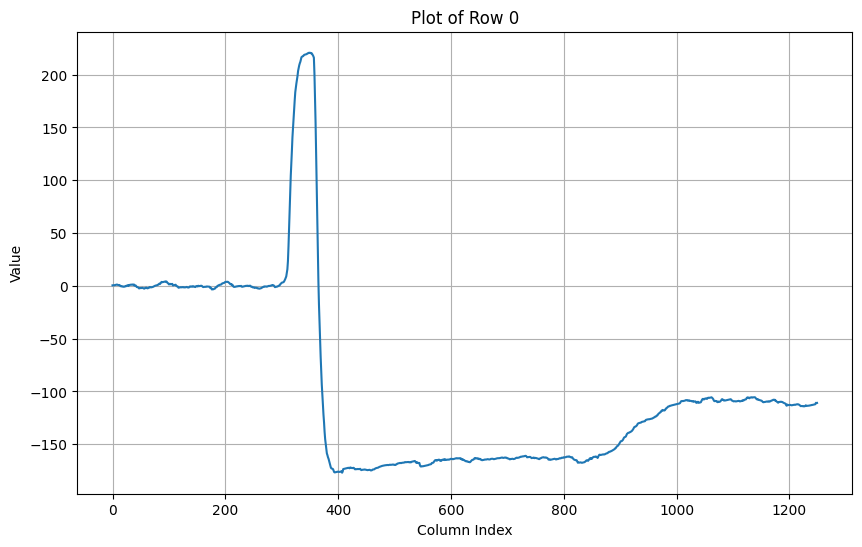

In [13]:
# plot one row in df

# Assuming we want to plot the first row (index 0) of the DataFrame
row_to_plot = df.iloc[0]

# Assuming 'target' is a column in our DataFrame and we want to exclude it
if 'target' in row_to_plot.index:
  row_to_plot = row_to_plot.drop('target')

plt.figure(figsize=(10, 6))
plt.plot(row_to_plot.values)
plt.xlabel('Column Index')
plt.ylabel('Value')
plt.title('Plot of Row 0')
plt.grid(True)
plt.show()

extract horizontal datas based on their labels as h1 to h12 variable:

In [14]:
h1 = []
h2 = []
h3 = []
h4 = []
h5 = []
h6 = []
h7 = []
h8 = []
h9 = []
h10 = []
h11 = []
h12 = []

for i in range(len(df)):
  temp = df.iloc[i]
  if temp['target'] == 1 :
    temp = temp.drop('target')
    h1.append(temp.astype(float).values)

  elif temp['target'] == 2 :
    temp = temp.drop('target')
    h2.append(temp.astype(float).values)

  elif temp['target'] == 3 :
    temp = temp.drop('target')
    h3.append(temp.astype(float).values)

  elif temp['target'] == 4 :
    temp = temp.drop('target')
    h4.append(temp.astype(float).values)

  elif temp['target'] == 5 :
    temp = temp.drop('target')
    h5.append(temp.astype(float).values)

  elif temp['target'] == 6 :
    temp = temp.drop('target')
    h6.append(temp.astype(float).values)

  elif temp['target'] == 7 :
    temp = temp.drop('target')
    h7.append(temp.astype(float).values)

  elif temp['target'] == 8 :
    temp = temp.drop('target')
    h8.append(temp.astype(float).values)

  elif temp['target'] == 9 :
    temp = temp.drop('target')
    h9.append(temp.astype(float).values)

  elif temp['target'] == 10 :
    temp = temp.drop('target')
    h10.append(temp.astype(float).values)

  elif temp['target'] == 11 :
    temp = temp.drop('target')
    h11.append(temp.astype(float).values)

  elif temp['target'] == 12 :
    temp = temp.drop('target')
    h12.append(temp.astype(float).values)

# **Download Dataset(vertical):**



In [15]:
!wget 'r' https://www.timeseriesclassification.com/aeon-toolkit/EOGVerticalSignal.zip

--2026-07-07 12:02:42--  http://r/
Resolving r (r)... failed: Name or service not known.
wget: unable to resolve host address ‘r’
--2026-07-07 12:02:42--  https://www.timeseriesclassification.com/aeon-toolkit/EOGVerticalSignal.zip
Resolving www.timeseriesclassification.com (www.timeseriesclassification.com)... 185.151.30.212
Connecting to www.timeseriesclassification.com (www.timeseriesclassification.com)|185.151.30.212|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8436384 (8.0M) [application/zip]
Saving to: ‘EOGVerticalSignal.zip’

EOGVerticalSignal.z 100%[===================>]   8.04M  5.11MB/s    in 1.6s    

2026-07-07 12:02:44 (5.11 MB/s) - ‘EOGVerticalSignal.zip’ saved [8436384/8436384]

FINISHED --2026-07-07 12:02:44--
Total wall clock time: 2.2s
Downloaded: 1 files, 8.0M in 1.6s (5.11 MB/s)


In [16]:
!unzip '/content/EOGVerticalSignal.zip'

Archive:  /content/EOGVerticalSignal.zip
  inflating: EOGVerticalSignal.txt   
  inflating: EOGVerticalSignal_TEST.arff  
  inflating: EOGVerticalSignal_TEST.txt  
  inflating: EOGVerticalSignal_TRAIN.arff  
  inflating: EOGVerticalSignal_TRAIN.txt  
replace README.md? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
  inflating: EOGVerticalSignal_TEST.ts  
  inflating: EOGVerticalSignal_TRAIN.ts  


In [17]:
# prompt: read  .arff file
data, meta = arff.loadarff('/content/EOGVerticalSignal_TRAIN.arff')
df = pd.DataFrame(data)
print(df.head())

      att1     att2     att3     att4     att5    att6    att7    att8  \
0 -5.70320 -5.89550 -5.88780 -6.08000 -6.17230 -6.2646 -6.2568 -6.1491   
1 -2.18020 -2.30860 -2.33690 -2.36520 -2.39360 -2.0219 -2.0502 -2.0786   
2  6.70950  6.52680  6.34420  6.16160  5.97900  5.7964  5.6137  4.5311   
3 -0.91251 -0.72238 -0.53226 -0.74213 -0.95201 -1.1619 -1.5718 -1.7816   
4 -5.44400 -5.32610 -4.10820 -3.69020 -3.57230 -3.4544 -3.0364 -2.6185   

     att9   att10  ...   att1242   att1243   att1244   att1245   att1246  \
0 -6.4414 -6.5336  ... -113.4100 -113.5000 -114.3900 -114.4800 -113.7700   
1 -2.5069 -3.2352  ...  108.5600  108.5300  108.5000  108.4700  108.4500   
2  2.7485  2.5659  ...  -35.1190  -35.3010  -35.4840  -35.6660  -34.9490   
3 -1.1915 -1.4014  ... -174.0700 -173.6800 -173.8900 -174.7000 -174.7100   
4 -2.5006 -2.3827  ...    1.8044    1.9223    2.0402    2.1582    2.2761   

   att1247   att1248   att1249   att1250  target  
0 -113.070 -113.1600 -112.8500 -112.9400    b'1

In [18]:
# prompt: read  .arff file
data, meta = arff.loadarff('/content/EOGVerticalSignal_TEST.arff')
df2 = pd.DataFrame(data)
print(df2.head())

      att1     att2     att3     att4     att5     att6     att7     att8  \
0   2.6752   2.6893   3.2034   4.0175   3.9315   3.9456   3.5597   3.8738   
1   6.8484   6.1714   5.6944   5.3173   5.1403   4.9633   4.1862   3.6092   
2  -4.9138  -4.8718  -4.8298  -4.9879  -5.1459  -4.5039  -4.6619  -3.7200   
3  18.2780  18.2900  18.3020  18.3140  18.3260  19.1380  19.1500  19.8620   
4  -6.2635  -6.2894  -6.0153  -5.3412  -5.4671  -6.0930  -6.7189  -6.3447   

      att9    att10  ...  att1242  att1243  att1244  att1245  att1246  \
0   3.4879   3.4019  ... -392.450 -391.240 -390.830 -390.710 -390.900   
1   2.7322   1.7551  ... -144.850 -144.220 -143.900 -143.680 -143.860   
2  -3.5780  -3.2360  ... -169.430 -169.590 -169.140 -169.100 -169.260   
3  19.1740  19.1860  ...  307.840  308.350  307.670  307.380  308.290   
4  -6.4706  -6.5965  ...   38.503   38.077   37.551   37.425   36.499   

   att1247  att1248  att1249  att1250  target  
0 -390.980 -390.870 -390.850 -390.740    b'1'  
1 

In [19]:
# concat df and df2
df_concat = pd.concat([df, df2], axis=0)

# Convert byte strings in 'target' to integers
df_concat['target'] = df_concat['target'].apply(lambda x: int(x.decode('utf-8')))

# Convert all 'att' columns to numeric, coercing errors, and then explicitly to float
att_columns = [col for col in df_concat.columns if col.startswith('att')]
df_concat[att_columns] = df_concat[att_columns].apply(pd.to_numeric, errors='coerce').astype(float)

df = df_concat
print(df.head())
print(df.info())

      att1     att2     att3     att4     att5    att6    att7    att8  \
0 -5.70320 -5.89550 -5.88780 -6.08000 -6.17230 -6.2646 -6.2568 -6.1491   
1 -2.18020 -2.30860 -2.33690 -2.36520 -2.39360 -2.0219 -2.0502 -2.0786   
2  6.70950  6.52680  6.34420  6.16160  5.97900  5.7964  5.6137  4.5311   
3 -0.91251 -0.72238 -0.53226 -0.74213 -0.95201 -1.1619 -1.5718 -1.7816   
4 -5.44400 -5.32610 -4.10820 -3.69020 -3.57230 -3.4544 -3.0364 -2.6185   

     att9   att10  ...   att1242   att1243   att1244   att1245   att1246  \
0 -6.4414 -6.5336  ... -113.4100 -113.5000 -114.3900 -114.4800 -113.7700   
1 -2.5069 -3.2352  ...  108.5600  108.5300  108.5000  108.4700  108.4500   
2  2.7485  2.5659  ...  -35.1190  -35.3010  -35.4840  -35.6660  -34.9490   
3 -1.1915 -1.4014  ... -174.0700 -173.6800 -173.8900 -174.7000 -174.7100   
4 -2.5006 -2.3827  ...    1.8044    1.9223    2.0402    2.1582    2.2761   

   att1247   att1248   att1249   att1250  target  
0 -113.070 -113.1600 -112.8500 -112.9400       

In [20]:
df = df_concat

extract vertical datas based on their labels as v1 to v12 variable:

In [21]:
v1 = []
v2 = []
v3 = []
v4 = []
v5 = []
v6 = []
v7 = []
v8 = []
v9 = []
v10 = []
v11 = []
v12 = []

for i in range(len(df)):
  temp = df.iloc[i]
  if temp['target'] == 1 :
    temp = temp.drop('target')
    v1.append(temp.astype(float).values)

  elif temp['target'] == 2 :
    temp = temp.drop('target')
    v2.append(temp.astype(float).values)

  elif temp['target'] == 3 :
    temp = temp.drop('target')
    v3.append(temp.astype(float).values)

  elif temp['target'] == 4 :
    temp = temp.drop('target')
    v4.append(temp.astype(float).values)

  elif temp['target'] == 5 :
    temp = temp.drop('target')
    v5.append(temp.astype(float).values)

  elif temp['target'] == 6 :
    temp = temp.drop('target')
    v6.append(temp.astype(float).values)

  elif temp['target'] == 7 :
    temp = temp.drop('target')
    v7.append(temp.astype(float).values)

  elif temp['target'] == 8 :
    temp = temp.drop('target')
    v8.append(temp.astype(float).values)

  elif temp['target'] == 9 :
    temp = temp.drop('target')
    v9.append(temp.astype(float).values)

  elif temp['target'] == 10 :
    temp = temp.drop('target')
    v10.append(temp.astype(float).values)

  elif temp['target'] == 11 :
    temp = temp.drop('target')
    v11.append(temp.astype(float).values)

  elif temp['target'] == 12 :
    temp = temp.drop('target')
    v12.append(temp.astype(float).values)

# **Distance :**

In [22]:
d1 = []
d2 = []
d3 = []
d4 = []
d5 = []
d6 = []
d7 = []
d8 = []
d9 = []
d10 = []
d11 = []
d12 = []



for i in range(len(v1)):
  d1.append(h1[i] - v1[i])

for i in range(len(v2)):
  d2.append(h2[i] - v2[i])

for i in range(len(v3)):
  d3.append(h3[i] - v3[i])

for i in range(len(v4)):
  d4.append(h4[i] - v4[i])

for i in range(len(v5)):
  d5.append(h5[i] - v5[i])

for i in range(len(v6)):
  d6.append(h6[i] - v6[i])

for i in range(len(v7)):
  d7.append(h7[i] - v7[i])

for i in range(len(v8)):
  d8.append(h8[i] - v8[i])

for i in range(len(v9)):
  d9.append(h9[i] - v9[i])

for i in range(len(v10)):
  d10.append(h10[i] - v10[i])

for i in range(len(v11)):
  d11.append(h11[i] - v11[i])

for i in range(len(v12)):
  d12.append(h12[i] - v12[i])



# **Concatenate with labels :**

In [23]:
x0 = []
label = 0
for series_data in h1:
  x0.append((series_data, label))

In [24]:
z0 = []
label = 0
for series_data in v1:
  z0.append((series_data, label))

In [25]:
k0 = []
label = 0
for series_data in d1:
  k0.append((series_data, label))

In [26]:
x1 = []
label = 1
for series_data in h2:
  x1.append((series_data, label))

In [27]:
z1 = []
label = 1
for series_data in v2:
  z1.append((series_data, label))

In [28]:
k1 = []
label = 1
for series_data in d2:
  k1.append((series_data, label))

In [29]:
x2 = []
label = 2
for series_data in h3:
  x2.append((series_data, label))

In [30]:
z2 = []
label = 2
for series_data in v3:
  z2.append((series_data, label))

In [31]:
k2 = []
label = 2
for series_data in d3:
  k2.append((series_data, label))

In [32]:
x3 = []
label = 3
for series_data in h4:
  x3.append((series_data, label))

In [33]:
z3 = []
label = 3
for series_data in v4:
  z3.append((series_data, label))

In [34]:
k3 = []
label = 3
for series_data in d4:
  k3.append((series_data, label))

In [35]:
x4 = []
label = 4
for series_data in h5:
  x4.append((series_data, label))

In [36]:
z4 = []
label = 4
for series_data in v5:
  z4.append((series_data, label))

In [37]:
k4 = []
label = 4
for series_data in d5:
  k4.append((series_data, label))

In [38]:
x5 = []
label = 5
for series_data in h6:
  x5.append((series_data, label))

In [39]:
z5 = []
label = 5
for series_data in v6:
  z5.append((series_data, label))

In [40]:
k5 = []
label = 5
for series_data in d6:
  k5.append((series_data, label))

In [41]:
x6 = []
label = 6
for series_data in h7:
  x6.append((series_data, label))

In [42]:
z6 = []
label = 6
for series_data in v7:
  z6.append((series_data, label))

In [43]:
k6 = []
label = 6
for series_data in d7:
  k6.append((series_data, label))

In [44]:
x7 = []
label = 7
for series_data in h8:
  x7.append((series_data, label))

In [45]:
z7 = []
label = 7
for series_data in v8:
  z7.append((series_data, label))

In [46]:
k7 = []
label = 7
for series_data in d8:
  k7.append((series_data, label))

In [47]:
x8 = []
label = 8
for series_data in h9:
  x8.append((series_data, label))

In [48]:
z8 = []
label = 8
for series_data in v9:
  z8.append((series_data, label))

In [49]:
k8 = []
label = 8
for series_data in d9:
  k8.append((series_data, label))

In [50]:
x9 = []
label = 9
for series_data in h10:
  x9.append((series_data, label))

In [51]:
z9 = []
label = 9
for series_data in v10:
  z9.append((series_data, label))

In [52]:
k9 = []
label = 9
for series_data in d10:
  k9.append((series_data, label))

In [53]:
x10 = []
label = 10
for series_data in h11:
  x10.append((series_data, label))

In [54]:
z10 = []
label = 10
for series_data in v11:
  z10.append((series_data, label))

In [55]:
k10 = []
label = 10
for series_data in d11:
  k10.append((series_data, label))

In [56]:
x11 = []
label = 11
for series_data in h12:
  x11.append((series_data, label))

In [57]:
z11 = []
label = 11
for series_data in v12:
  z11.append((series_data, label))

In [58]:
k11 = []
label = 11
for series_data in d12:
  k11.append((series_data, label))

In [59]:
x2[1]

(array([ 4.1914,  4.1491,  4.1068, ..., 97.921 , 97.878 , 97.436 ]), 2)

In [60]:
len(x1)

60

In [61]:
len(x2)

60

In [62]:
len(x1+x2)

120

In [63]:
x = x0 + x1 + x2 + x3 + x4 + x5 + x6 + x7 + x8 + x9 + x10 + x11

In [64]:
z = z0 + z1 + z2 + z3 + z4 + z5 + z6 + z7 + z8 + z9 + z10 + z11

In [65]:
k = k0 + k1 + k2 + k3 + k4 + k5 + k6 + k7 + k8 + k9 + k10 + k11

In [66]:
x[0]

(array([   0.47769,    0.60965,    0.44162, ..., -110.76   , -111.03   ,
        -110.9    ]),
 0)

In [67]:
x_horizontal = np.array([data[0] for data in x])
y_horizontal = np.array([data[1] for data in x])
y_horizontal_categorical = to_categorical([data[1] for data in x])

In [68]:
x_horizontal.shape

(724, 1250)

In [69]:
y_horizontal.shape

(724,)

In [70]:
y_horizontal_categorical.shape

(724, 12)

In [71]:
x_vertical = np.array([data[0] for data in z])
y_vertical = np.array([data[1] for data in z])
y_vertical_categorical = to_categorical([data[1] for data in z])

In [72]:
x_vertical.shape

(724, 1250)

In [73]:
x_distance = np.array([data[0] for data in k])
y_distance = np.array([data[1] for data in k])
y_distance_categorical = to_categorical([data[1] for data in k])

In [74]:
x_distance.shape

(724, 1250)

# **Train & Test :**

In [85]:
import tensorflow as tf
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import KFold

# Define the part model structure
def create_model():
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense, Dropout, GlobalAveragePooling1D # Changed imports
    from tensorflow.keras.optimizers import Adam

    model = Sequential([
        Conv1D(16, 3, activation='relu', input_shape=(1250, 1)), 
        MaxPooling1D(pool_size=2),
        Conv1D(32, 3, activation='relu'), 
        GlobalAveragePooling1D(), 
        Dense(32, activation='relu'),
        Dropout(0.5),
        Dense(12, activation='softmax')
    ])
    model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
    return model


# Define k-fold cross-validation
k_folds = 5
kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)


# Total epochs and chunk parameters
total_epochs = 600
chunk_size = 100
num_chunks = total_epochs // chunk_size

# Initialize lists to store confusion matrices across folds
confusion_matrices_part1 = []
confusion_matrices_part2 = []
confusion_matrices_part3 = []
confusion_matrices_final = []

for fold, (train_idx, val_idx) in enumerate(kf.split(x_horizontal)):
    print(f"\n=== Starting Fold {fold + 1}/{k_folds} ===\n")


    # Create models for Part1, Part2, and Part3
    part1_model = create_model()
    part2_model = create_model()
    part3_model = create_model()

    # Create the Final Model
    final_model = tf.keras.Sequential([
        tf.keras.layers.Dense(16, activation='relu', input_shape=(36,)),
        tf.keras.layers.Dense(12, activation='softmax')  # Number of classes = 12
    ])
    final_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])



    # Split data into training and validation sets
    X_horizontal_train, X_horizontal_val = x_horizontal[train_idx], x_horizontal[val_idx]
    X_vertical_train, X_vertical_val = x_vertical[train_idx], x_vertical[val_idx]
    X_distance_train, X_distance_val = x_distance[train_idx], x_distance[val_idx]

    # Reshape data for Conv1D
    X_horizontal_train = X_horizontal_train.reshape(X_horizontal_train.shape[0], X_horizontal_train.shape[1], 1)
    X_horizontal_val = X_horizontal_val.reshape(X_horizontal_val.shape[0], X_horizontal_val.shape[1], 1)
    X_vertical_train = X_vertical_train.reshape(X_vertical_train.shape[0], X_vertical_train.shape[1], 1)
    X_vertical_val = X_vertical_val.reshape(X_vertical_val.shape[0], X_vertical_val.shape[1], 1)
    X_distance_train = X_distance_train.reshape(X_distance_train.shape[0], X_distance_train.shape[1], 1)
    X_distance_val = X_distance_val.reshape(X_distance_val.shape[0], X_distance_val.shape[1], 1)


    # Split labels into training and validation sets
    y_horizontal_train, y_horizontal_val = y_horizontal_categorical[train_idx], y_horizontal_categorical[val_idx]
    y_vertical_train, y_vertical_val = y_vertical_categorical[train_idx], y_vertical_categorical[val_idx]
    y_distance_train, y_distance_val = y_distance_categorical[train_idx], y_distance_categorical[val_idx]

    # Training Part1 model
    print("\nTraining Part1 model with x_horizontal inputs and y_horizontal_categorical labels...\n")
    for chunk in range(num_chunks):
        print(f"Training Part1 Chunk {chunk + 1}/{num_chunks}")
        part1_model.fit(X_horizontal_train, y_horizontal_train, epochs=chunk_size, batch_size=32, verbose=1)
        part1_model.save(f'part1_model_fold_{fold + 1}_chunk_{chunk + 1}.h5')

    part1_model.trainable = False

    # Training Part2 model
    print("\nTraining Part2 model with x_vertical inputs and y_vertical_categorical labels...\n")
    for chunk in range(num_chunks):
        print(f"Training Part2 Chunk {chunk + 1}/{num_chunks}")
        part2_model.fit(X_vertical_train, y_vertical_train, epochs=chunk_size, batch_size=32, verbose=1)
        part2_model.save(f'part2_model_fold_{fold + 1}_chunk_{chunk + 1}.h5')

    part2_model.trainable = False

    # Training Part3 model
    print("\nTraining Part3 model with x_distance inputs and y_distance_categorical labels...\n")
    for chunk in range(num_chunks):
        print(f"Training Part3 Chunk {chunk + 1}/{num_chunks}")
        part3_model.fit(X_distance_train, y_distance_train, epochs=chunk_size, batch_size=32, verbose=1)
        part3_model.save(f'part3_model_fold_{fold + 1}_chunk_{chunk + 1}.h5')

    part3_model.trainable = False

    # Training Final Model
    print("\nTraining Final Model on combined features...\n")
    for chunk in range(num_chunks):
        print(f"Training Final Model Chunk {chunk + 1}/{num_chunks}")

        # Combine features for training the final model
        part1_output_train = part1_model.predict(X_horizontal_train)
        part2_output_train = part2_model.predict(X_vertical_train)
        part3_output_train = part3_model.predict(X_distance_train)

        combined_features_train = np.concatenate((part1_output_train, part2_output_train, part3_output_train), axis=1)

        # Train the final model using combined features
        final_model.fit(combined_features_train, y_horizontal_train, epochs=chunk_size, batch_size=32, verbose=1)
        final_model.save(f'final_model_fold_{fold + 1}_chunk_{chunk + 1}.h5')
        print(f'Final Model saved: final_model_fold_{fold + 1}_chunk_{chunk + 1}.h5')

    # Validation
    print("\nEvaluating Final Model on validation set...\n")
    part1_output_val = part1_model.predict(X_horizontal_val)
    part2_output_val = part2_model.predict(X_vertical_val)
    part3_output_val = part3_model.predict(X_distance_val)

    combined_features_val = np.concatenate((part1_output_val, part2_output_val, part3_output_val), axis=1)
    final_preds = np.argmax(final_model.predict(combined_features_val), axis=1)

    part1_preds = np.argmax(part1_model.predict(X_horizontal_val), axis=1)
    part2_preds = np.argmax(part2_model.predict(X_vertical_val), axis=1)
    part3_preds = np.argmax(part3_model.predict(X_distance_val), axis=1)
    true_labels = np.argmax(y_horizontal_val, axis=1)  # Using y_horizontal_val for comparison

    # Confusion matrices
    cm_part1 = confusion_matrix(true_labels, part1_preds, labels=range(12))
    cm_part2 = confusion_matrix(true_labels, part2_preds, labels=range(12))
    cm_part3 = confusion_matrix(true_labels, part3_preds, labels=range(12))
    cm_final = confusion_matrix(true_labels, final_preds, labels=range(12))

    # Append confusion matrices
    confusion_matrices_part1.append(cm_part1)
    confusion_matrices_part2.append(cm_part2)
    confusion_matrices_part3.append(cm_part3)
    confusion_matrices_final.append(cm_final)

# Calculate and display mean confusion matrices
mean_cm_part1 = np.mean(confusion_matrices_part1, axis=0)
mean_cm_part2 = np.mean(confusion_matrices_part2, axis=0)
mean_cm_part3 = np.mean(confusion_matrices_part3, axis=0)
mean_cm_final = np.mean(confusion_matrices_final, axis=0)

print("\nMean Confusion Matrix - Part1:\n", mean_cm_part1)
print("\nMean Confusion Matrix - Part2:\n", mean_cm_part2)
print("\nMean Confusion Matrix - Part3:\n", mean_cm_part3)
print("\nMean Confusion Matrix - Final Model:\n", mean_cm_final)

# Save the mean confusion matrix of the final model
np.save('mean_confusion_matrix_final.npy', mean_cm_final)
print("\nMean Confusion Matrix for Final Model saved as 'mean_confusion_matrix_final.npy'.")


=== Starting Fold 1/5 ===


Training Part1 model with x_horizontal inputs and y_horizontal_categorical labels...

Training Part1 Chunk 1/6
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 128ms/step - accuracy: 0.0708 - loss: 21.1939
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1002 - loss: 6.8695
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1036 - loss: 3.2822
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1295 - loss: 2.5927
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1209 - loss: 2.4501
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1468 - loss: 2.4139
Epoch 7/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1364 - loss: 2.3994
Epoch 8/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1416 - loss: 2.3964
Epoch 9/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1727 - loss: 2.4010
Epoch 10/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1693 - loss: 2.3264
Epoch 11/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1416 - loss: 2.3539
Epoch 12/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1451 -

Training Part1 Chunk 2/6
Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2314 - loss: 1.9810
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2591 - loss: 1.9194
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2366 - loss: 1.9566
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2539 - loss: 1.9547
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2418 - loss: 1.9476
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2349 - loss: 1.9726
Epoch 7/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2712 - loss: 1.9392
Epoch 8/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2625 - loss: 1.9339
Epoch 9/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2453 - loss: 1.9165
Epoch 10/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2366 - loss: 1.9299
Epoch 11/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2470 - loss: 1.9439
Epoch 12/100
19/19 ━━━━━━━━━━━━━━━━━━━

Training Part1 Chunk 3/6
Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3040 - loss: 1.8033
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2936 - loss: 1.8139
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3126 - loss: 1.7678
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2815 - loss: 1.8073
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3057 - loss: 1.8305
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2884 - loss: 1.8101
Epoch 7/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3126 - loss: 1.8124
Epoch 8/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3022 - loss: 1.7970
Epoch 9/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2902 - loss: 1.8247
Epoch 10/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3299 - loss: 1.7417
Epoch 11/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3109 - loss: 1.7892
Epoch 12/100
19/19 ━━━━━━━━━━━━━━━━━━━

...

Final Model saved: final_model_fold_5_chunk_2.h5
Training Final Model Chunk 3/6
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7862 - loss: 0.5950
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7966 - loss: 0.5935
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7862 - loss: 0.5933
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7845 - loss: 0.5922
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7897 - loss: 0.5918
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7897 - loss: 0.5905
Epoch 7/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7897 - loss: 0.5902
Epoch 8/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7828 - loss: 0.5909
Epoch 9/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7879 - loss: 0.5888
Epoch 10/100
19/19 ━━━━━━━━━━━━━━━━

Final Model saved: final_model_fold_5_chunk_3.h5
Training Final Model Chunk 4/6
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8121 - loss: 0.5445
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8052 - loss: 0.5449
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8017 - loss: 0.5437
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8069 - loss: 0.5439
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8138 - loss: 0.5442
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8121 - loss: 0.5432
Epoch 7/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8121 - loss: 0.5427
Epoch 8/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8190 - loss: 0.5418
Epoch 9/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8103 - loss: 0.5416
Epoch 10/100
19/19 ━━━━━━━━━━━━━━━━━

Final Model saved: final_model_fold_5_chunk_4.h5
Training Final Model Chunk 5/6
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8155 - loss: 0.5099
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8190 - loss: 0.5105
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8172 - loss: 0.5096
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8172 - loss: 0.5094
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8172 - loss: 0.5086
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8172 - loss: 0.5105
Epoch 7/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8207 - loss: 0.5090
Epoch 8/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8172 - loss: 0.5086
Epoch 9/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8190 - loss: 0.5080
Epoch 10/100
19/19 ━━━━━━━━━━━━━━━━━

Final Model saved: final_model_fold_5_chunk_5.h5
Training Final Model Chunk 6/6
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8155 - loss: 0.4840
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8172 - loss: 0.4827
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8172 - loss: 0.4827
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8155 - loss: 0.4833
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8121 - loss: 0.4860
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8172 - loss: 0.4845
Epoch 7/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8155 - loss: 0.4828
Epoch 8/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8172 - loss: 0.4827
Epoch 9/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8172 - loss: 0.4827
Epoch 10/100
19/19 ━━━━━━━━━━━━━━━━━━━

Final Model saved: final_model_fold_5_chunk_6.h5

Evaluating Final Model on validation set...

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 176ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 

Mean Confusion Matrix - Part1:
 [[ 2.   0.   0.4  0.2  0.2  0.4  0.   4.8  0.   3.4  0.2  0.4]
 [ 0.   5.4  0.8  0.   0.2  0.2  0.   0.   1.8  0.   0.   3.6]
 [ 0.   0.8  9.6  0.   0.   0.2  0.4  0.   0.2  0.   0.6  0.2]
 [ 2.8  0.4  0.4  0.   1.4  1.6  0.   1.4  0.4  3.   0.4  0.2]
 [ 0.8  0.4  0.2  0.6  1.2  2.2  0.   2.4  0.4  4.   0.   0. ]
 [ 0.2  0.   0.   0.   0.6  9.2  0.4  1.   0.4  0.4  0.   0. ]
 [ 0.   0.   0.   0.   0.   0.4  9.4  0.   0.   0.   2.4  0. ]
 [ 1.   0.   0.   0.   0.4  0.4  0.   9.   0.   1.2  0.   0. ]
 [ 0.   0.4  0.   0.   0.2  0.   0.   0.2 10.6  0.8  0.   0. ]
 [ 2.4  0.   0.2  0.   1.4  0.4  0.   

In [88]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score


def calculate_metrics(confusion_matrix_val, model_name):
    num_classes = confusion_matrix_val.shape[0]
    precision = []
    recall = []
    f1 = []

    for i in range(num_classes):
        true_positives = confusion_matrix_val[i, i]
        false_positives = np.sum(confusion_matrix_val[:, i]) - true_positives
        false_negatives = np.sum(confusion_matrix_val[i, :]) - true_positives

        # Handle division by zero for precision and recall
        prec = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
        rec = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0

        # Handle division by zero for f1_score
        f1_scr = 2 * (prec * rec) / (prec + rec) if (prec + rec) > 0 else 0

        precision.append(prec)
        recall.append(rec)
        f1.append(f1_scr)

    # Macro-average the metrics
    macro_precision = np.mean(precision)
    macro_recall = np.mean(recall)
    macro_f1 = np.mean(f1)

    print(f"\n--- {model_name} Metrics ---")
    print(f"Accuracy: {np.trace(confusion_matrix_val) / np.sum(confusion_matrix_val):.4f}")
    print(f"Macro Precision: {macro_precision:.4f}")
    print(f"Macro Recall: {macro_recall:.4f}")
    print(f"Macro F1-score: {macro_f1:.4f}")


# Calculate and print metrics for Part1
calculate_metrics(mean_cm_part1, "Part1 Model")

# Calculate and print metrics for Part2
calculate_metrics(mean_cm_part2, "Part2 Model")

# Calculate and print metrics for Part3
calculate_metrics(mean_cm_part3, "Part3 Model")

# Calculate and print metrics for Final Model
calculate_metrics(mean_cm_final, "Final Model")


--- Part1 Model Metrics ---
Accuracy: 0.4917
Macro Precision: 0.4443
Macro Recall: 0.4913
Macro F1-score: 0.4561

--- Part2 Model Metrics ---
Accuracy: 0.4738
Macro Precision: 0.4621
Macro Recall: 0.4732
Macro F1-score: 0.4480

--- Part3 Model Metrics ---
Accuracy: 0.1782
Macro Precision: 0.4197
Macro Recall: 0.1778
Macro F1-score: 0.1849

--- Final Model Metrics ---
Accuracy: 0.8191
Macro Precision: 0.8224
Macro Recall: 0.8188
Macro F1-score: 0.8188


In [89]:
accuracies_part1 = []
accuracies_part2 = []
accuracies_part3 = []
accuracies_final = []

# Function to calculate accuracy from a confusion matrix
def get_accuracy_from_cm(cm):
    return np.trace(cm) / np.sum(cm)

# Calculate accuracies for each fold for Part1 Model
for cm in confusion_matrices_part1:
    accuracies_part1.append(get_accuracy_from_cm(cm))

# Calculate accuracies for each fold for Part2 Model
for cm in confusion_matrices_part2:
    accuracies_part2.append(get_accuracy_from_cm(cm))

# Calculate accuracies for each fold for Part3 Model
for cm in confusion_matrices_part3:
    accuracies_part3.append(get_accuracy_from_cm(cm))

# Calculate accuracies for each fold for Final Model
for cm in confusion_matrices_final:
    accuracies_final.append(get_accuracy_from_cm(cm))

# Report mean and variance of accuracies for each model
print("\n--- Mean and Variance of Accuracies across folds ---")
print(f"Part1 Model - Mean Accuracy: {np.mean(accuracies_part1):.4f}, Variance: {np.var(accuracies_part1):.4f}")
print(f"Part2 Model - Mean Accuracy: {np.mean(accuracies_part2):.4f}, Variance: {np.var(accuracies_part2):.4f}")
print(f"Part3 Model - Mean Accuracy: {np.mean(accuracies_part3):.4f}, Variance: {np.var(accuracies_part3):.4f}")
print(f"Final Model - Mean Accuracy: {np.mean(accuracies_final):.4f}, Variance: {np.var(accuracies_final):.4f}")


--- Mean and Variance of Accuracies across folds ---
Part1 Model - Mean Accuracy: 0.4916, Variance: 0.0047
Part2 Model - Mean Accuracy: 0.4736, Variance: 0.0109
Part3 Model - Mean Accuracy: 0.1783, Variance: 0.0329
Final Model - Mean Accuracy: 0.8189, Variance: 0.0057


In [90]:
accuracies_part1

[np.float64(0.5517241379310345),
 np.float64(0.496551724137931),
 np.float64(0.45517241379310347),
 np.float64(0.5724137931034483),
 np.float64(0.3819444444444444)]

In [91]:
accuracies_part2

[np.float64(0.503448275862069),
 np.float64(0.6413793103448275),
 np.float64(0.4827586206896552),
 np.float64(0.41379310344827586),
 np.float64(0.3263888888888889)]

In [92]:
accuracies_part3

[np.float64(0.04827586206896552),
 np.float64(0.5103448275862069),
 np.float64(0.04827586206896552),
 np.float64(0.04827586206896552),
 np.float64(0.2361111111111111)]

In [93]:
accuracies_final

[np.float64(0.7931034482758621),
 np.float64(0.9241379310344827),
 np.float64(0.8344827586206897),
 np.float64(0.8482758620689655),
 np.float64(0.6944444444444444)]

In [94]:
print(f"Part1 Model Parameters: {part1_model.count_params()}")
print(f"Part2 Model Parameters: {part2_model.count_params()}")
print(f"Part3 Model Parameters: {part3_model.count_params()}")
print(f"Final Model Parameters: {final_model.count_params()}")

total_params = part1_model.count_params() + part2_model.count_params() + part3_model.count_params() + final_model.count_params()
print(f"\nTotal Parameters (all models combined): {total_params}")

if total_params < 100000:
    complexity = "Low"
elif total_params < 1000000:
    complexity = "Medium"
else:
    complexity = "High"
print(f"Model Complexity: {complexity}")

Part1 Model Parameters: 3084
Part2 Model Parameters: 3084
Part3 Model Parameters: 3084
Final Model Parameters: 796

Total Parameters (all models combined): 10048
Model Complexity: Low
